# Climatological Assessment of Ross Island and the Ross Ice Shelf of Antarctica with a Focus on November 2024 Anomalies
### AOS573 Final Project - Kathryn Marek

### Introduction

Antarctica’s extreme environment makes it one of the most challenging regions on Earth to observe, yet understanding its surface weather is essential for climate research, logistical planning, and long-term environmental monitoring. Automatic Weather Stations (AWS) play a critical role in this effort by providing continuous, ground-based measurements in places where human presence is scarce. A study of the Ross Ice Shelf (RIS), which surrounds Ross Island, highlights this importance, describing the AWS network as capturing a “surface climatology” for one of the most "meteorologically active and variable regions on the continent" (Costanza et al., 2016). These stations, supported by the Antarctic Meteorological Research and Data Center (AMRDC), offer invaluable long-term datasets that enhance our understanding of Antarctic weather patterns, surface energy budgets, and the environmental drivers shaping the region.

My project investigates the climatology of Ross Island and the surrounding Ross Ice Shelf, with particular attention to conditions during November 2024. Scientists from the Antarctic Meteorological Research and Data Center (AMRDC) reported unusually severe weather during their field season that limited field operations, raising the question of whether these conditions were climatologically anomalous. Given the breadth of available AWS data in this region, this study narrows its analysis to November 2005-2024 as an initial window into potential anomalies. Ideally, extending the analysis to include November, December, and January, the typical core AMRDC field season, would provide a more comprehensive assessment of seasonal variability and strengthen conclusions about how unusual the 2024 conditions truly were. 

**GUIDING QUESTION**
> How did temperature, wind, and atmospheric pressure during November 2024 at Ross Island and the surrounding ice shelves compare to the 2005–2023 November climatology?

> Were the observed conditions in 2024 significantly different from the long-term mean, and which variables exhibited the largest anomalies?

> Were there specific high-wind or low-pressure events that could've contributed to extreme weather conditions in November 2024, and did these events cluster at particular times during the month?

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats

### Data Aquisition
Data for this study was obtained from the Antarctic Meteorological Research and Data Center (AMRDC) via their public repository ([AWS Q10 archive)](https://amrc.ssec.wisc.edu/data/ftp/pub/aws/q10/
). The dataset consists of automatic weather station (AWS) observations across Antarctica. For this project, I selected data from 2005 through 2024, focusing on individual stations for the month of November.

### Reading in the data

In [2]:
path_phx = '/tornado/home1/class/fall24/kjmarek/AOS573 Final Project/final_project/Final Project /Data/phx/'
path_wdb = '/tornado/home1/class/fall24/kjmarek/AOS573 Final Project/final_project/Final Project /Data/wdb/'
path_lda = '/tornado/home1/class/fall24/kjmarek/AOS573 Final Project/final_project/Final Project /Data/lda/'
path_fer = '/tornado/home1/class/fall24/kjmarek/AOS573 Final Project/final_project/Final Project /Data/fer/'
path_cbd = '/tornado/home1/class/fall24/kjmarek/AOS573 Final Project/final_project/Final Project /Data/cbd/'
path_lor = '/tornado/home1/class/fall24/kjmarek/AOS573 Final Project/final_project/Final Project /Data/lor/'
path_lr2 = '/tornado/home1/class/fall24/kjmarek/AOS573 Final Project/final_project/Final Project /Data/lr2/'


In [3]:
# Define which years each station has data for
station_years = {
    'phx': [2017, 2018, 2020, 2021, 2023, 2024],
    'wdb': [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'lda': [2006, 2007, 2009, 2010, 2011, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'fer': [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'cbd': [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'lor': [2007, 2008, 2009, 2010, 2012, 2013, 2014, 2015, 2016, 2019, 2020, 2021, 2022, 2023, 2024],
    'lr2': [2006, 2008, 2009, 2010, 2011, 2012, 2013, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
}

# Station paths
station_paths = {
    'phx': path_phx, 'wdb': path_wdb, 'lda': path_lda, 'fer': path_fer,
    'cbd': path_cbd, 'lor': path_lor, 'lr2': path_lr2
}

# Column names
col_names = ["Year", "Julian day", "Month", "Day", "Ten minute observation time (UTC)", 
             "Temperature (C)", "Pressure (hPa)", "Wind Speed (m/s)", "Wind Direction", 
             "Relative Humidity (%)", "Delta-T (C)"]

# Read all data using loops
all_station_data = {}
for station_code, years in station_years.items():
    station_list = []
    for year in years:
        filename = f"{station_code}{year}11q10.txt"
        filepath = station_paths[station_code] + filename
        df = pd.read_csv(filepath, skiprows=2, header=None, sep=r'\s+', 
                        na_values=444.0, names=col_names)
        station_list.append(df)
    all_station_data[station_code] = station_list

# Create all_stations dictionary with full names
all_stations = {
    'Phoenix': all_station_data['phx'],
    'Windless Bight': all_station_data['wdb'],
    'Linda': all_station_data['lda'],
    'Ferrell': all_station_data['fer'],
    'Cape Bird': all_station_data['cbd'],
    'Lorne': all_station_data['lor'],
    'Laurie II': all_station_data['lr2']
}

### Interpreting AWS Data
Each AWS dataset used in this project contains ten-minute observations for a given station and month, providing a high-resolution view of local atmospheric conditions. Each file includes time fields (year, Julian day, month, day, and UTC observation time) followed by key meteorological variables: air temperature (°C), station pressure (hPa), wind speed (m/s), wind direction (degrees), relative humidity (%), and Delta-T (°C), which represents the temperature–dew point difference and serves as an indicator of atmospheric dryness. This structure is consistent across all stations and all years, allowing for straightforward comparison of November conditions from 2005–2024. The example shown below illustrates the format.

In [4]:
# Here's an example displaying a specific station and year
all_station_data['lr2'][0]  # First year (2006) for Laurie II

,Year,Julian day,Month,Day,Ten minute observation time (UTC),Temperature (C),Pressure (hPa),Wind Speed (m/s),Wind Direction,Relative Humidity (%),Delta-T (C)
0,2006,305,11,1,0,-23.9,978.3,8.2,184.0,51.8,NaN
1,2006,305,11,1,10,-23.6,978.4,7.2,188.0,51.4,NaN
2,2006,305,11,1,20,-23.5,978.6,6.8,169.0,50.9,NaN
3,2006,305,11,1,30,-23.4,978.6,6.4,194.0,50.5,NaN
4,2006,305,11,1,40,-23.4,978.5,6.4,193.0,50.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4315,2006,334,11,30,2310,-4.6,983.2,2.7,176.0,56.6,NaN
4316,2006,334,11,30,2320,-4.8,983.2,3.1,160.0,58.8,NaN
4317,2006,334,11,30,2330,-4.1,983.2,1.6,155.0,57.5,NaN
4318,2006,334,11,30,2340,NaN,NaN,NaN,NaN,NaN,NaN


### Locating the AWS

This map shows the locations of the Automatic Weather Stations (AWS) used in this study across Ross Island and the surrounding Ross Ice Shelf (light blue). Plotting these sites provides important spatial context for interpreting the climatology of the region and the variability captured in the November datasets.

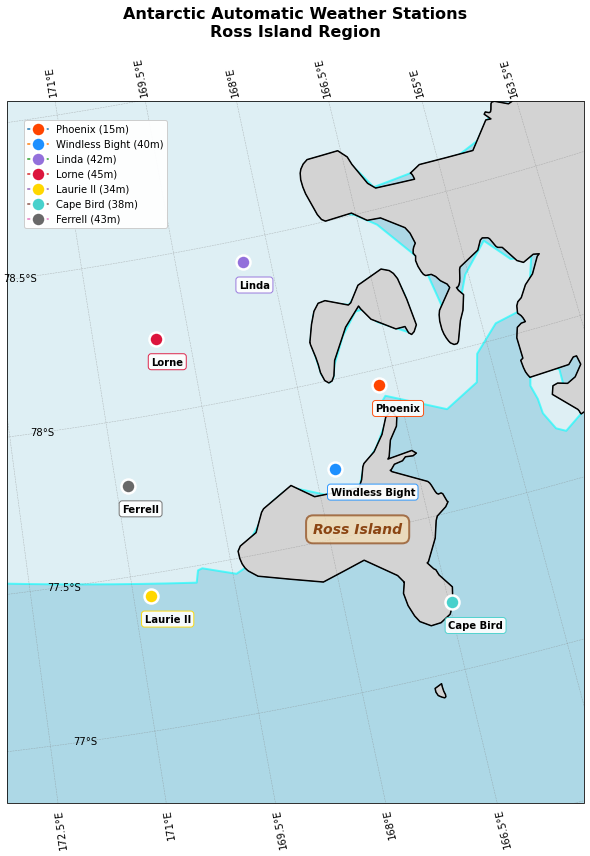

In [5]:
# Color for each station to keep it consistent
stations = {
    'Phoenix': {'lat': -77.95, 'lon': 166.76, 'elev': 15, 'color': 'orangered'},
    'Windless Bight': {'lat': -77.72, 'lon': 167.70, 'elev': 40, 'color': 'dodgerblue'},
    'Linda': {'lat': -78.43, 'lon': 168.43, 'elev': 42, 'color': 'mediumpurple'},
    'Lorne': {'lat': -78.24, 'lon': 170.01, 'elev': 45, 'color': 'crimson'},
    'Laurie II': {'lat': -77.43, 'lon': 170.75, 'elev': 34, 'color': 'gold'},
    'Cape Bird': {'lat': -77.22, 'lon': 166.45, 'elev': 38, 'color': 'mediumturquoise'},
    'Ferrell': {'lat': -77.79, 'lon': 170.82, 'elev': 43, 'color': 'dimgray'}
}

# Ross Island location
ross_island = {'lat': -77.514306, 'lon': 167.563972}

# Create figure with Antarctic Polar Stereographic projection
fig = plt.figure(figsize=(14, 12))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

# Set the extent to focus on Ross Island and Ross Ice Shelf 
ax.set_extent([165, 172, -78.8, -76.8], crs=ccrs.PlateCarree())

# Add features in correct order (bottom to top)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)

# Use Natural Earth to add ice shelves 
try:
    ax.add_feature(cfeature.NaturalEarthFeature(
        'physical', 'antarctic_ice_shelves_polys', '50m',
        edgecolor='cyan', facecolor='white', alpha=0.6, linewidth=2
    ), zorder=1)
except:
    print("Ice shelf data downloading or not available at this resolution")

# Add land, coastline
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5, zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1.5, zorder=3)

# Add lat/lon gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', 
                   alpha=0.5, linestyle='--')

# Add a nice Ross Island Label 
ax.text(ross_island['lon'], ross_island['lat'], 'Ross Island', 
        transform=ccrs.PlateCarree(),
        fontsize=14, fontweight='bold', style='italic',
        color='saddlebrown',
        horizontalalignment='center', verticalalignment='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', 
                 edgecolor='saddlebrown', alpha=0.7, linewidth=2),
        zorder=10)

# Plot stations in distinct colors and provide a key 
for name, info in stations.items():
    ax.plot(info['lon'], info['lat'], 
            marker='o', markersize=14, 
            markerfacecolor=info['color'], 
            markeredgecolor='white', 
            markeredgewidth=2.5,
            transform=ccrs.PlateCarree(),
            label=f"{name} ({info['elev']}m)", zorder=100)
    
    ax.text(info['lon'] + 0.15, info['lat'] + 0.08, name, 
            transform=ccrs.PlateCarree(),
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor=info['color'], alpha=0.9), zorder=101)

ax.set_title('Antarctic Automatic Weather Stations\nRoss Island Region', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=10, framealpha=0.95, 
          bbox_to_anchor=(0.02, 0.98))

plt.tight_layout()
plt.show()

### Record-breaking Variable Analysis

In [6]:
# This combines all data across all stations
all_data_combined = []
for station_name, station_data_list in all_stations.items():
    for df in station_data_list:
        df_copy = df.copy()
        df_copy['Station'] = station_name
        all_data_combined.append(df_copy)

all_data = pd.concat(all_data_combined, ignore_index=True)
november_data = all_data[all_data['Month'] == 11].copy()

# Create full datetime for precise timestamps
november_data['FullDateTime'] = pd.to_datetime(
    november_data['Year'].astype(str) + '-' + 
    november_data['Month'].astype(str) + '-' + 
    november_data['Day'].astype(str) + ' ' +
    (november_data['Ten minute observation time (UTC)'] // 100).astype(str) + ':' +
    (november_data['Ten minute observation time (UTC)'] % 100).astype(str)
)

# Temperature records
# coldest temperature
coldest_idx = november_data['Temperature (C)'].idxmin()
coldest_record = november_data.loc[coldest_idx]
print(f"\nColdest Temperature:")
print(f"  Value: {coldest_record['Temperature (C)']:.2f}°C")
print(f"  Date/Time: {coldest_record['FullDateTime']}")
print(f"  Station: {coldest_record['Station']}")

# Warmest temperature
warmest_idx = november_data['Temperature (C)'].idxmax()
warmest_record = november_data.loc[warmest_idx]
print(f"\nWarmest Temperature:")
print(f"  Value: {warmest_record['Temperature (C)']:.2f}°C")
print(f"  Date/Time: {warmest_record['FullDateTime']}")
print(f"  Station: {warmest_record['Station']}")


# Wind Speed records
# Highest wind speed
highest_wind_idx = november_data['Wind Speed (m/s)'].idxmax()
highest_wind_record = november_data.loc[highest_wind_idx]
print(f"\nHighest Wind Speed:")
print(f"  Value: {highest_wind_record['Wind Speed (m/s)']:.2f} m/s ({highest_wind_record['Wind Speed (m/s)']*3.6:.2f} km/h)")
print(f"  Date/Time: {highest_wind_record['FullDateTime']}")
print(f"  Station: {highest_wind_record['Station']}")
print(f"  Wind Direction: {highest_wind_record['Wind Direction']:.0f}°")
print(f"  Temperature during event: {highest_wind_record['Temperature (C)']:.2f}°C")

# Lowest wind speed (calm)
lowest_wind_idx = november_data['Wind Speed (m/s)'].idxmin()
lowest_wind_record = november_data.loc[lowest_wind_idx]
print(f"\nLowest Wind Speed:")
print(f"  Value: {lowest_wind_record['Wind Speed (m/s)']:.2f} m/s")
print(f"  Date/Time: {lowest_wind_record['FullDateTime']}")
print(f"  Station: {lowest_wind_record['Station']}")

# Pressure Records
# Lowest pressure
lowest_pressure_idx = november_data['Pressure (hPa)'].idxmin()
lowest_pressure_record = november_data.loc[lowest_pressure_idx]
print(f"\nLowest Pressure (Deepest Cyclone):")
print(f"  Value: {lowest_pressure_record['Pressure (hPa)']:.2f} hPa")
print(f"  Date/Time: {lowest_pressure_record['FullDateTime']}")
print(f"  Station: {lowest_pressure_record['Station']}")
print(f"  Temperature during event: {lowest_pressure_record['Temperature (C)']:.2f}°C")
print(f"  Wind Speed during event: {lowest_pressure_record['Wind Speed (m/s)']:.2f} m/s")

# Highest pressure
highest_pressure_idx = november_data['Pressure (hPa)'].idxmax()
highest_pressure_record = november_data.loc[highest_pressure_idx]
print(f"\nHighest Pressure:")
print(f"  Value: {highest_pressure_record['Pressure (hPa)']:.2f} hPa")
print(f"  Date/Time: {highest_pressure_record['FullDateTime']}")
print(f"  Station: {highest_pressure_record['Station']}")
print(f"  Temperature during event: {highest_pressure_record['Temperature (C)']:.2f}°C")
print(f"  Wind Speed during event: {highest_pressure_record['Wind Speed (m/s)']:.2f} m/s")

# Relative Humidity REcords
# Highest humidity
highest_humidity_idx = november_data['Relative Humidity (%)'].idxmax()
highest_humidity_record = november_data.loc[highest_humidity_idx]
print(f"\nHigest Relative Humidity:")
print(f"  Value: {highest_humidity_record['Relative Humidity (%)']:.1f}%")
print(f"  Date/Time: {highest_humidity_record['FullDateTime']}")
print(f"  Station: {highest_humidity_record['Station']}")
print(f"  Temperature during event: {highest_humidity_record['Temperature (C)']:.2f}°C")

# Lowest humidity
lowest_humidity_idx = november_data['Relative Humidity (%)'].idxmin()
lowest_humidity_record = november_data.loc[lowest_humidity_idx]
print(f"\nLowest Relative Humidity:")
print(f"  Value: {lowest_humidity_record['Relative Humidity (%)']:.1f}%")
print(f"  Date/Time: {lowest_humidity_record['FullDateTime']}")
print(f"  Station: {lowest_humidity_record['Station']}")
print(f"  Temperature during event: {lowest_humidity_record['Temperature (C)']:.2f}°C")

# Delta-T Records
# Highest Delta-T (driest conditions!)
highest_deltat_idx = november_data['Delta-T (C)'].idxmax()
highest_deltat_record = november_data.loc[highest_deltat_idx]
print(f"\nHigjest Delta-T (Driest Air):")
print(f"  Value: {highest_deltat_record['Delta-T (C)']:.2f}°C")
print(f"  Date/Time: {highest_deltat_record['FullDateTime']}")
print(f"  Station: {highest_deltat_record['Station']}")
print(f"  Temperature: {highest_deltat_record['Temperature (C)']:.2f}°C")
print(f"  Relative Humidity: {highest_deltat_record['Relative Humidity (%)']:.1f}%")

# Lowest Delta-T (most saturated)
lowest_deltat_idx = november_data['Delta-T (C)'].idxmin()
lowest_deltat_record = november_data.loc[lowest_deltat_idx]
print(f"\nLowest Delta-T (Most Saturated Air):")
print(f"  Value: {lowest_deltat_record['Delta-T (C)']:.2f}°C")
print(f"  Date/Time: {lowest_deltat_record['FullDateTime']}")
print(f"  Station: {lowest_deltat_record['Station']}")
print(f"  Temperature: {lowest_deltat_record['Temperature (C)']:.2f}°C")
print(f"  Relative Humidity: {lowest_deltat_record['Relative Humidity (%)']:.1f}%")

# 2024 Specific records
print("2024 Records:")

nov_2024 = november_data[november_data['Year'] == 2024]

if len(nov_2024) > 0:
    # 2024 Temp extremes
    print("\n2024 Temperature:")
    coldest_2024_idx = nov_2024['Temperature (C)'].idxmin()
    coldest_2024 = nov_2024.loc[coldest_2024_idx]
    print(f"  Coldest: {coldest_2024['Temperature (C)']:.2f}°C on {coldest_2024['FullDateTime']} at {coldest_2024['Station']}")
    
    warmest_2024_idx = nov_2024['Temperature (C)'].idxmax()
    warmest_2024 = nov_2024.loc[warmest_2024_idx]
    print(f"  Warmest: {warmest_2024['Temperature (C)']:.2f}°C on {warmest_2024['FullDateTime']} at {warmest_2024['Station']}")
    
    # 2024 Wind extremes
    print("\n2024 Wind Speed:")
    windiest_2024_idx = nov_2024['Wind Speed (m/s)'].idxmax()
    windiest_2024 = nov_2024.loc[windiest_2024_idx]
    print(f"  Highest: {windiest_2024['Wind Speed (m/s)']:.2f} m/s on {windiest_2024['FullDateTime']} at {windiest_2024['Station']}")
    
    calmest_2024_idx = nov_2024['Wind Speed (m/s)'].idxmin()
    calmest_2024 = nov_2024.loc[calmest_2024_idx]
    print(f"  Lowest: {calmest_2024['Wind Speed (m/s)']:.2f} m/s on {calmest_2024['FullDateTime']} at {calmest_2024['Station']}")
    
    # 2024 Pressure extremes
    print("\n2024 Pressure:")
    lowest_p_2024_idx = nov_2024['Pressure (hPa)'].idxmin()
    lowest_p_2024 = nov_2024.loc[lowest_p_2024_idx]
    print(f"  Lowest: {lowest_p_2024['Pressure (hPa)']:.2f} hPa on {lowest_p_2024['FullDateTime']} at {lowest_p_2024['Station']}")
    
    highest_p_2024_idx = nov_2024['Pressure (hPa)'].idxmax()
    highest_p_2024 = nov_2024.loc[highest_p_2024_idx]
    print(f"  Highest: {highest_p_2024['Pressure (hPa)']:.2f} hPa on {highest_p_2024['FullDateTime']} at {highest_p_2024['Station']}")



Coldest Temperature:
  Value: -34.00°C
  Date/Time: 2007-11-02 15:30:00
  Station: Windless Bight

Warmest Temperature:
  Value: 3.60°C
  Date/Time: 2013-11-25 05:20:00
  Station: Cape Bird

Highest Wind Speed:
  Value: 39.00 m/s (140.40 km/h)
  Date/Time: 2010-11-04 02:00:00
  Station: Cape Bird
  Wind Direction: 188°
  Temperature during event: -11.60°C

Lowest Wind Speed:
  Value: 0.00 m/s
  Date/Time: 2017-11-28 16:00:00
  Station: Phoenix

Lowest Pressure (Deepest Cyclone):
  Value: 945.70 hPa
  Date/Time: 2010-11-01 04:20:00
  Station: Cape Bird
  Temperature during event: -13.40°C
  Wind Speed during event: 8.20 m/s

Highest Pressure:
  Value: 1011.80 hPa
  Date/Time: 2011-11-03 15:00:00
  Station: Windless Bight
  Temperature during event: -22.90°C
  Wind Speed during event: 1.10 m/s

Higest Relative Humidity:
  Value: 100.3%
  Date/Time: 2022-11-26 03:30:00
  Station: Windless Bight
  Temperature during event: -9.60°C

Lowest Relative Humidity:
  Value: 0.0%
  Date/Time: 2011

The record-breaking values across the 2005–2024 November climatology highlight the extreme variability that characterizes the Ross Island region. Temperature extremes span from a frigid –34.0°C (Windless Bight, 2007) to an unusually warm 3.6°C (Cape Bird, 2013). Wind extremes are particularly striking: the highest recorded wind speed reached 39.0 m/s (75.8 knots) at Cape Bird in 2010. Pressure records further reinforce this variability, with the deepest recorded November cyclone dropping to 945.7 hPa in 2010, one of the more intense November pressure minima observed on the Ross Ice Shelf. Relative humidity and delta-T extremes show equally dramatic swings, from supersaturated conditions (100.3% RH, 2022) to extremely dry air masses (Delta-T of 12°C, 2016). Collectively, the long-term record illustrates that strong winds, deep cyclones, and large thermodynamic variability are normal components of the region’s November climate.

Although November 2024 did not set any all-time records for temperature, wind, or pressure in the Ross Island region, the AWS data suggest that conditions were still unusual. The coldest temperature reached −27.20°C at Lorne, and the warmest was only −3.60°C at Laurie II, while wind speeds peaked at 28.10 m/s at Cape Bird. Pressures ranged from 958.10 to 997.20 hPa. None of these values exceed the historical extremes recorded between 2005 and 2024 at these seven chosen stations, yet the combination of relatively low temperatures, high wind speeds, and moderately low pressures over the month indicates that November 2024 experienced persistently cold and windy conditions, which may have contributed to the fieldwork difficulties reported by AMRDC scientists. Even without setting records, the possibility of sustained extreme conditions makes it worth investigating. Let's dive in deeper!

# Temperature Variability around Ross Island

This figure shows November mean temperatures from 2005–2024 for seven AWS sites on and around Ross Island. Each line represents a station’s year-to-year variability. 

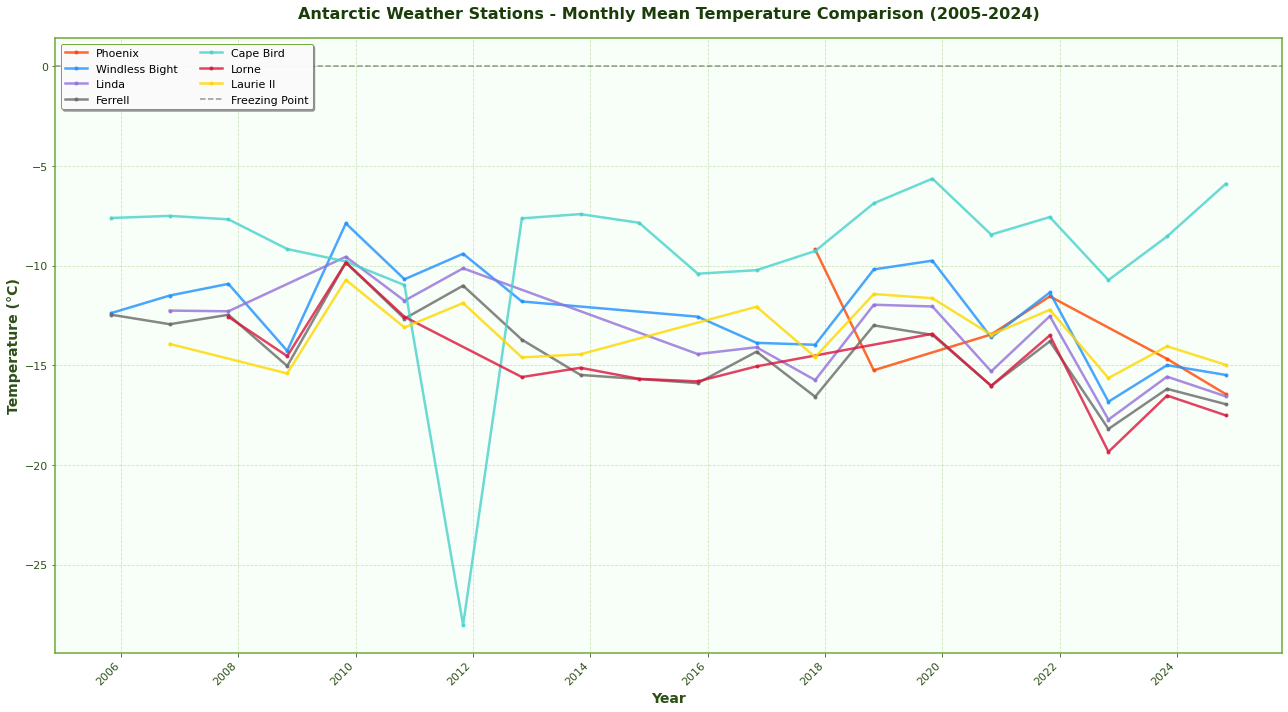


Phoenix:
  Overall Mean (all years): -13.43°C
  2024 Mean (November):     -16.45°C
  2024 Anomaly:             -3.02°C (cooler)
  Min: -16.45°C  |  Max: -9.18°C  |  Std: 2.67°C
  Number of months: 6

Windless Bight:
  Overall Mean (all years): -12.30°C
  2024 Mean (November):     -15.48°C
  2024 Anomaly:             -3.18°C (cooler)
  Min: -16.83°C  |  Max: -7.88°C  |  Std: 2.35°C
  Number of months: 18

Linda:
  Overall Mean (all years): -13.46°C
  2024 Mean (November):     -16.56°C
  2024 Anomaly:             -3.09°C (cooler)
  Min: -17.73°C  |  Max: -9.55°C  |  Std: 2.38°C
  Number of months: 15

Ferrell:
  Overall Mean (all years): -14.21°C
  2024 Mean (November):     -16.95°C
  2024 Anomaly:             -2.74°C (cooler)
  Min: -18.19°C  |  Max: -9.84°C  |  Std: 2.15°C
  Number of months: 19

Cape Bird:
  Overall Mean (all years): -9.36°C
  2024 Mean (November):     -5.89°C
  2024 Anomaly:             +3.47°C (warmer)
  Min: -28.03°C  |  Max: -5.63°C  |  Std: 4.65°C
  Number of mo

In [7]:
# Get colors from station dictionary 
station_colors = {name: info['color'] for name, info in stations.items()}

# Create figure
fig, ax = plt.subplots(figsize=(18, 10))

# Store monthly data for statistics
station_monthly_data = {}

# Process each station
for station_name, station_data_list in all_stations.items():
    # Combine all data for this station
    station_combined = []
    for df in station_data_list:
        df_copy = df.copy()
        station_combined.append(df_copy)
    
    station_df = pd.concat(station_combined, ignore_index=True)
    
    # Create datetime
    station_df['DateTime'] = pd.to_datetime(
        station_df['Year'].astype(str) + '-' + 
        station_df['Month'].astype(str) + '-' + 
        station_df['Day'].astype(str)
    )
    
    # Calculate monthly means
    station_df['YearMonth'] = station_df['DateTime'].dt.to_period('M')
    monthly_means = station_df.groupby('YearMonth')['Temperature (C)'].mean().reset_index()
    monthly_means['DateTime'] = monthly_means['YearMonth'].dt.to_timestamp()
    monthly_means['Year'] = monthly_means['YearMonth'].dt.year
    
    # Store for statistics
    station_monthly_data[station_name] = monthly_means
    
    # Plot with gaps for missing years
    ax.plot(monthly_means['DateTime'], monthly_means['Temperature (C)'],
            color=station_colors[station_name], linewidth=2.5, 
            label=station_name, marker='o', markersize=3, alpha=0.8)

# Styling
ax.set_xlabel('Year', fontsize=14, fontweight='bold', color='#2d5016')
ax.set_ylabel('Temperature (°C)', fontsize=14, fontweight='bold', color='#2d5016')
ax.set_title('Antarctic Weather Stations - Monthly Mean Temperature Comparison (2005-2024)', 
             fontsize=16, fontweight='bold', pad=20, color='#1a3d0a')

# Add horizontal line at 0°C
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.4, label='Freezing Point')

# Grid
ax.grid(True, alpha=0.3, linestyle='--', color='#6ba832', linewidth=0.8)

# Legend
ax.legend(loc='upper left', fontsize=11, framealpha=0.95, 
          facecolor='white', edgecolor='#6ba832', shadow=True, ncol=2)

# Background colors
ax.set_facecolor('#f8fff8')
fig.patch.set_facecolor('white')

# Spine colors
for spine in ax.spines.values():
    spine.set_edgecolor('#6ba832')
    spine.set_linewidth(1.5)

# Tick styling
ax.tick_params(colors='#2d5016', labelsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary statistics for monthly means (what's actually plotted)
for station_name, monthly_data in station_monthly_data.items():
    temps = monthly_data['Temperature (C)']
    temp_mean_all = temps.mean()
    temp_min = temps.min()
    temp_max = temps.max()
    temp_std = temps.std()
    
    # Calculate 2024 average
    temps_2024 = monthly_data[monthly_data['Year'] == 2024]['Temperature (C)']
    if len(temps_2024) > 0:
        temp_mean_2024 = temps_2024.mean()
        anomaly = temp_mean_2024 - temp_mean_all
        has_2024 = True
    else:
        temp_mean_2024 = None
        anomaly = None
        has_2024 = False
    
    print(f"\n{station_name}:")
    print(f"  Overall Mean (all years): {temp_mean_all:.2f}°C")
    if has_2024:
        print(f"  2024 Mean (November):     {temp_mean_2024:.2f}°C")
        print(f"  2024 Anomaly:             {anomaly:+.2f}°C {'(warmer)' if anomaly > 0 else '(cooler)' if anomaly < 0 else '(same)'}")
    else:
        print(f"  2024 Mean:                No data")
    print(f"  Min: {temp_min:.2f}°C  |  Max: {temp_max:.2f}°C  |  Std: {temp_std:.2f}°C")
    print(f"  Number of months: {len(temps)}")

November 2024 stood out as a particularly cold month for most of the automated weather stations on and around Ross Island. Six of the seven stations (Phoenix, Windless Bight, Linda, Ferrell, Lorne, and Laurie II) experienced substantial negative temperature anomalies, ranging from approximately –1.6°C to –3.2°C compared to their long-term November means. These departures are outside the typical monthly variability indicated by their standard deviations, suggesting a strong regional cold event affecting the ice shelff and nearby inland areas.

In contrast, Cape Bird, a station located closer to the coast, recorded a positive anomaly of +3.47°C, reflecting a local warming relative to its climatology. However, it appears that the year 2007 was an extreme outlier year, dragging the mean down significantly. This difference highlights how local geography, particularly proximity to open water, can modulate extreme temperature responses. Overall, the pattern suggests that November 2024 had unusually cold air over most of the Ross Island region while leaving some coastal locations relatively warmer.

### November 2024 Climatological Anomalies

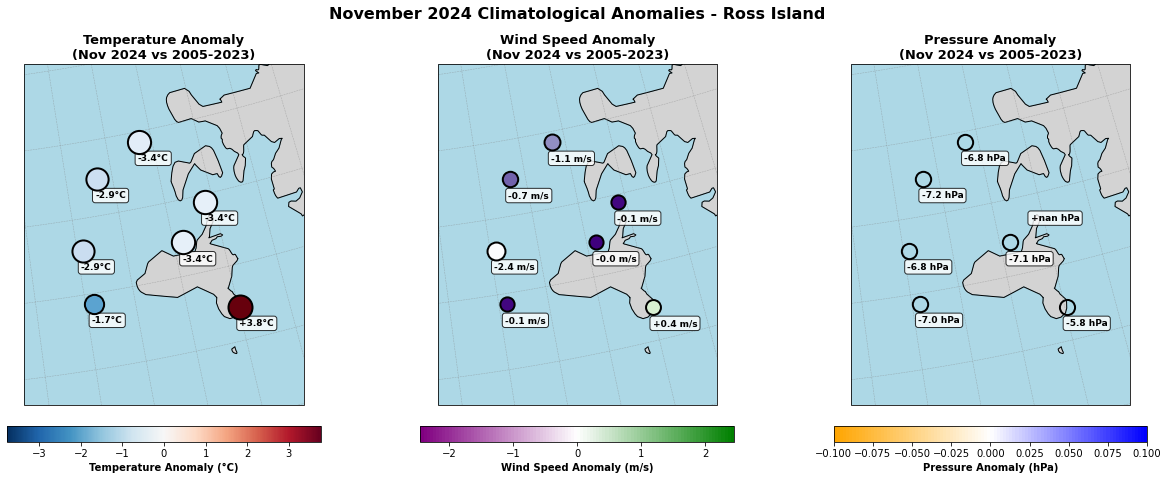

In [8]:
# calculate November climatology (2005-2023) and 2024 anomalies for each station
station_anomalies = {}

for station_name, station_data_list in all_stations.items():
    station_df = pd.concat(station_data_list, ignore_index=True)
    nov_data = station_df[station_df['Month'] == 11].copy()
    nov_clim = nov_data[nov_data['Year'] != 2024]
    nov_2024 = nov_data[nov_data['Year'] == 2024]
    
    if len(nov_2024) > 0 and len(nov_clim) > 0:
        station_anomalies[station_name] = {
            'temp_anomaly': nov_2024['Temperature (C)'].mean() - nov_clim['Temperature (C)'].mean(),
            'wind_anomaly': nov_2024['Wind Speed (m/s)'].mean() - nov_clim['Wind Speed (m/s)'].mean(),
            'pressure_anomaly': nov_2024['Pressure (hPa)'].mean() - nov_clim['Pressure (hPa)'].mean(),
            'temp_2024': nov_2024['Temperature (C)'].mean(),
            'temp_clim': nov_clim['Temperature (C)'].mean()
        }

# Creates anomaly maps
fig = plt.figure(figsize=(18, 7))

# Temperature anomaly map
ax1 = plt.subplot(1, 3, 1, projection=ccrs.SouthPolarStereo())
ax1.set_extent([165, 172, -78.8, -76.8], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax1.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax1.add_feature(cfeature.COASTLINE, linewidth=1)
ax1.gridlines(linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

temp_anomalies = [station_anomalies[name]['temp_anomaly'] for name in station_anomalies.keys()]
abs_max_temp = max(abs(min(temp_anomalies)), abs(max(temp_anomalies)))

for station_name in station_anomalies.keys():
    anomaly = station_anomalies[station_name]['temp_anomaly']
    lat = stations[station_name]['lat']
    lon = stations[station_name]['lon']
    
    color = plt.cm.Blues_r(abs(anomaly) / abs_max_temp) if anomaly < 0 else plt.cm.Reds(anomaly / abs_max_temp)
    size = 200 + abs(anomaly) * 100
    
    ax1.plot(lon, lat, marker='o', markersize=np.sqrt(size), 
            markerfacecolor=color, markeredgecolor='black', 
            markeredgewidth=2, transform=ccrs.PlateCarree(), zorder=5)
    
    ax1.text(lon + 0.15, lat + 0.12, f'{anomaly:+.1f}°C', 
            transform=ccrs.PlateCarree(), fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor='black', alpha=0.8))

ax1.set_title('Temperature Anomaly\n(Nov 2024 vs 2005-2023)', fontsize=13, fontweight='bold')

# Temp Colorbar 
sm1 = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=-abs_max_temp, vmax=abs_max_temp))
sm1.set_array([])
cbar1 = plt.colorbar(sm1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7)
cbar1.set_label('Temperature Anomaly (°C)', fontsize=10, fontweight='bold')

# Windspeed anomaly map
ax2 = plt.subplot(1, 3, 2, projection=ccrs.SouthPolarStereo())
ax2.set_extent([165, 172, -78.8, -76.8], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax2.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax2.add_feature(cfeature.COASTLINE, linewidth=1)
ax2.gridlines(linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

wind_anomalies = [station_anomalies[name]['wind_anomaly'] for name in station_anomalies.keys()]
abs_max_wind = max(abs(min(wind_anomalies)), abs(max(wind_anomalies)))

for station_name in station_anomalies.keys():
    anomaly = station_anomalies[station_name]['wind_anomaly']
    lat = stations[station_name]['lat']
    lon = stations[station_name]['lon']
    
    color = plt.cm.Purples_r(abs(anomaly) / abs_max_wind) if anomaly < 0 else plt.cm.Greens(anomaly / abs_max_wind)
    size = 200 + abs(anomaly) * 50
    
    ax2.plot(lon, lat, marker='o', markersize=np.sqrt(size), 
            markerfacecolor=color, markeredgecolor='black', 
            markeredgewidth=2, transform=ccrs.PlateCarree(), zorder=5)
    
    ax2.text(lon + 0.15, lat + 0.12, f'{anomaly:+.1f} m/s', 
            transform=ccrs.PlateCarree(), fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor='black', alpha=0.8))

ax2.set_title('Wind Speed Anomaly\n(Nov 2024 vs 2005-2023)', fontsize=13, fontweight='bold')

# Wind speed colorbar
from matplotlib.colors import LinearSegmentedColormap
colors_wind = ['purple', 'white', 'green']
n_bins = 100
cmap_wind = LinearSegmentedColormap.from_list('wind', colors_wind, N=n_bins)
sm2 = plt.cm.ScalarMappable(cmap=cmap_wind, norm=plt.Normalize(vmin=-abs_max_wind, vmax=abs_max_wind))
sm2.set_array([])
cbar2 = plt.colorbar(sm2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7)
cbar2.set_label('Wind Speed Anomaly (m/s)', fontsize=10, fontweight='bold')

# pressure anomaly map 
ax3 = plt.subplot(1, 3, 3, projection=ccrs.SouthPolarStereo())
ax3.set_extent([165, 172, -78.8, -76.8], crs=ccrs.PlateCarree())
ax3.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax3.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax3.add_feature(cfeature.COASTLINE, linewidth=1)
ax3.gridlines(linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

pressure_anomalies = [station_anomalies[name]['pressure_anomaly'] for name in station_anomalies.keys()]
abs_max_pressure = max(abs(min(pressure_anomalies)), abs(max(pressure_anomalies)))

for station_name in station_anomalies.keys():
    anomaly = station_anomalies[station_name]['pressure_anomaly']
    lat = stations[station_name]['lat']
    lon = stations[station_name]['lon']
    
    color = plt.cm.Oranges_r(abs(anomaly) / abs_max_pressure) if anomaly < 0 else plt.cm.Blues(anomaly / abs_max_pressure)
    size = 200 + abs(anomaly) * 5
    
    ax3.plot(lon, lat, marker='o', markersize=np.sqrt(size), 
            markerfacecolor=color, markeredgecolor='black', 
            markeredgewidth=2, transform=ccrs.PlateCarree(), zorder=5)
    
    ax3.text(lon + 0.15, lat + 0.12, f'{anomaly:+.1f} hPa', 
            transform=ccrs.PlateCarree(), fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor='black', alpha=0.8))

ax3.set_title('Pressure Anomaly\n(Nov 2024 vs 2005-2023)', fontsize=13, fontweight='bold')

# Pressure colorbar
colors_pressure = ['orange', 'white', 'blue']
cmap_pressure = LinearSegmentedColormap.from_list('pressure', colors_pressure, N=n_bins)
sm3 = plt.cm.ScalarMappable(cmap=cmap_pressure, norm=plt.Normalize(vmin=-abs_max_pressure, vmax=abs_max_pressure))
sm3.set_array([])
cbar3 = plt.colorbar(sm3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7)
cbar3.set_label('Pressure Anomaly (hPa)', fontsize=10, fontweight='bold')

fig.suptitle('November 2024 Climatological Anomalies - Ross Island', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

The November 2024 anomaly maps reveal spatially heterogeneous but predominantly colder-than-average conditions across the Ross Island region relative to the 2005–2023 climatology. With the exception of Cape Bird, which exhibits a notable warm anomaly (+3.8 °C), all stations show negative temperature anomalies ranging from approximately −1.7 °C to −3.4 °C, indicating broadly cooler conditions during the month. Wind speed anomalies are generally weakly negative, suggesting slightly calmer-than-average conditions at most sites, though the magnitudes are small. In contrast, pressure anomalies are consistently negative across nearly all stations (approx. −5 to −7 hPa), pointing to a regionally lower-pressure environment during November 2024. Taken together, these anomalies further suggest that November 2024 was characterized by widespread below-normal temperatures and anomalously low surface pressure, conditions consistent with enhanced synoptic activity influencing the Ross Island region.

### Extreme Event Analysis

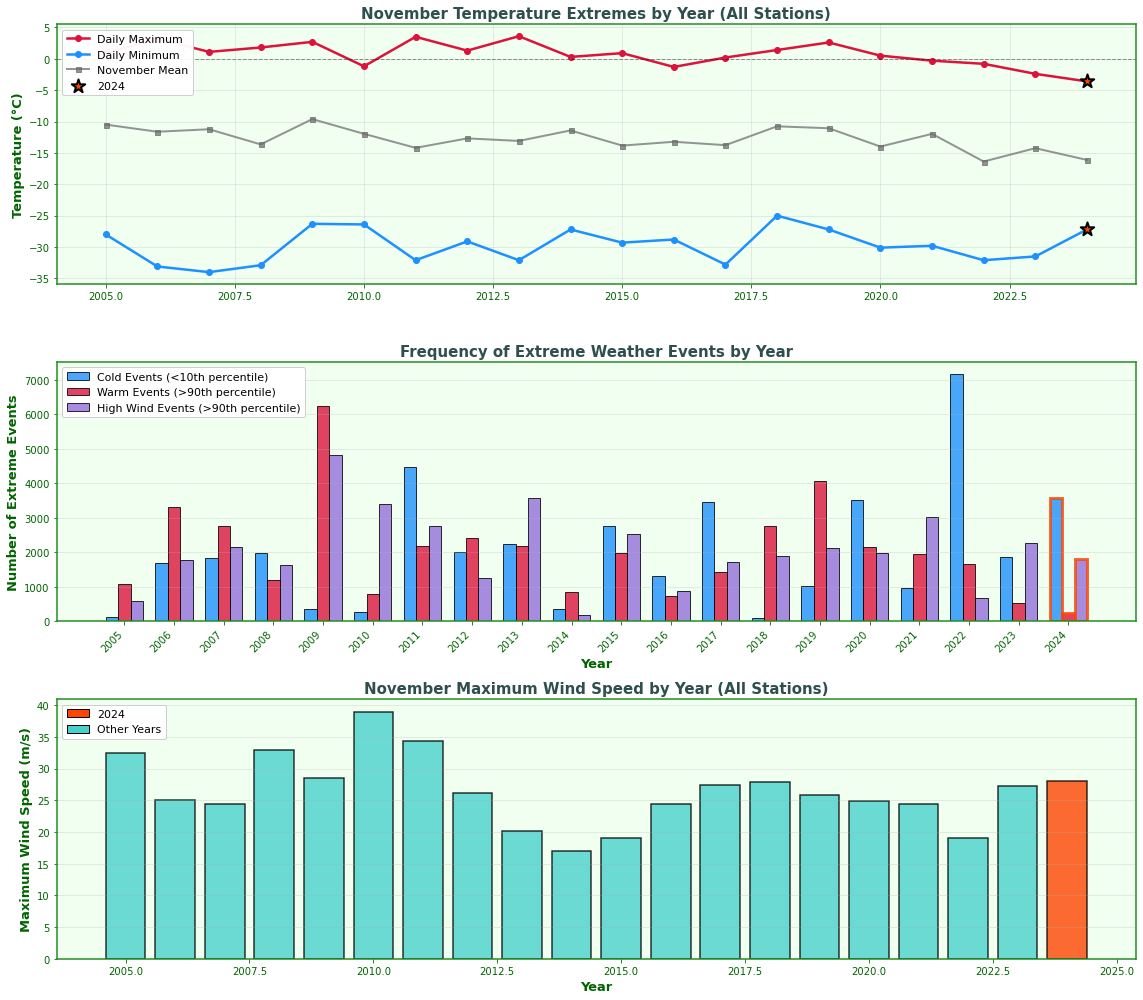


Thresholds (based on all November data 2005-2024):
  Cold Event: < -20.90°C (10th percentile)
  Warm Event: > -5.90°C (90th percentile)
  High Wind Event: > 10.70 m/s (90th percentile)

2024 November Extremes:
  Coldest Temperature: -27.20°C
  Warmest Temperature: -3.60°C
  Maximum Wind Speed: 28.10 m/s

Record Analysis:
  Coldest ever? False
  Warmest ever? False
  Windiest ever? False

2024 Extreme Event Counts:
  Cold Events: 3570
  Warm Events: 256
  High Wind Events: 1823


In [9]:
# Calc daily extremes for each year
yearly_extremes = november_data.groupby('Year').agg({
    'Temperature (C)': ['min', 'max', 'mean'],
    'Wind Speed (m/s)': ['max', 'mean']
}).reset_index()

yearly_extremes.columns = ['Year', 'Temp_Min', 'Temp_Max', 'Temp_Mean', 'Wind_Max', 'Wind_Mean']

# Define extreme thresholds (based on percentiles across all data )
temp_cold_threshold = november_data['Temperature (C)'].quantile(0.10)  # Bottom 10%
temp_warm_threshold = november_data['Temperature (C)'].quantile(0.90)  # top 10%
wind_high_threshold = november_data['Wind Speed (m/s)'].quantile(0.90)  # Top 10%

# Count extreme events by year
extreme_counts = []
for year in sorted(november_data['Year'].unique()):
    year_data = november_data[november_data['Year'] == year]
    
    cold_events = (year_data['Temperature (C)'] < temp_cold_threshold).sum()
    warm_events = (year_data['Temperature (C)'] > temp_warm_threshold).sum()
    high_wind_events = (year_data['Wind Speed (m/s)'] > wind_high_threshold).sum()
    
    extreme_counts.append({
        'Year': year,
        'Cold_Events': cold_events,
        'Warm_Events': warm_events,
        'High_Wind_Events': high_wind_events
    })

extreme_df = pd.DataFrame(extreme_counts)

# Create figure and subplots
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Subplot 1 temp extremes over time 
ax1 = axes[0]
ax1.plot(yearly_extremes['Year'], yearly_extremes['Temp_Max'], 
         color='crimson', linewidth=2.5, marker='o', markersize=6, label='Daily Maximum')
ax1.plot(yearly_extremes['Year'], yearly_extremes['Temp_Min'], 
         color='dodgerblue', linewidth=2.5, marker='o', markersize=6, label='Daily Minimum')
ax1.plot(yearly_extremes['Year'], yearly_extremes['Temp_Mean'], 
         color='dimgray', linewidth=2, marker='s', markersize=5, label='November Mean', alpha=0.7)

# highlight 2024
if 2024 in yearly_extremes['Year'].values:
    year_2024_data = yearly_extremes[yearly_extremes['Year'] == 2024].iloc[0]
    ax1.scatter([2024], [year_2024_data['Temp_Max']], s=200, color='orangered', 
                marker='*', edgecolors='black', linewidth=2, zorder=10, label='2024')
    ax1.scatter([2024], [year_2024_data['Temp_Min']], s=200, color='orangered', 
                marker='*', edgecolors='black', linewidth=2, zorder=10)

ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.4)
ax1.set_ylabel('Temperature (°C)', fontsize=13, fontweight='bold', color='darkgreen')
ax1.set_title('November Temperature Extremes by Year (All Stations)', 
              fontsize=15, fontweight='bold', color='darkslategray')
ax1.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('honeydew')

# Subplot 2 extreme event freq
ax2 = axes[1]
width = 0.25
x = extreme_df['Year']
x_pos = np.arange(len(x))

bars1 = ax2.bar(x_pos - width, extreme_df['Cold_Events'], width, 
                label='Cold Events (<10th percentile)', color='dodgerblue', alpha=0.8, edgecolor='black')
bars2 = ax2.bar(x_pos, extreme_df['Warm_Events'], width, 
                label='Warm Events (>90th percentile)', color='crimson', alpha=0.8, edgecolor='black')
bars3 = ax2.bar(x_pos + width, extreme_df['High_Wind_Events'], width, 
                label='High Wind Events (>90th percentile)', color='mediumpurple', alpha=0.8, edgecolor='black')

# Highlight 2024 bars
if 2024 in extreme_df['Year'].values:
    idx_2024 = extreme_df[extreme_df['Year'] == 2024].index[0]
    bars1[idx_2024].set_edgecolor('orangered')
    bars1[idx_2024].set_linewidth(3)
    bars2[idx_2024].set_edgecolor('orangered')
    bars2[idx_2024].set_linewidth(3)
    bars3[idx_2024].set_edgecolor('orangered')
    bars3[idx_2024].set_linewidth(3)

ax2.set_ylabel('Number of Extreme Events', fontsize=13, fontweight='bold', color='darkgreen')
ax2.set_xlabel('Year', fontsize=13, fontweight='bold', color='darkgreen')
ax2.set_title('Frequency of Extreme Weather Events by Year', 
              fontsize=15, fontweight='bold', color='darkslategray')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x, rotation=45, ha='right')
ax2.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_facecolor('honeydew')

# Subplot 3  max wind speed by year
ax3 = axes[2]
colors_wind = ['orangered' if year == 2024 else 'mediumturquoise' for year in yearly_extremes['Year']]
ax3.bar(yearly_extremes['Year'], yearly_extremes['Wind_Max'], 
        color=colors_wind, alpha=0.8, edgecolor='black', linewidth=1.5)

ax3.set_ylabel('Maximum Wind Speed (m/s)', fontsize=13, fontweight='bold', color='darkgreen')
ax3.set_xlabel('Year', fontsize=13, fontweight='bold', color='darkgreen')
ax3.set_title('November Maximum Wind Speed by Year (All Stations)', 
              fontsize=15, fontweight='bold', color='darkslategray')
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_facecolor('honeydew')

# Legend for 2024 highlight
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='orangered', edgecolor='black', label='2024'),
                   Patch(facecolor='mediumturquoise', edgecolor='black', label='Other Years')]
ax3.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.95)

# Style stuff 
for ax in axes:
    for spine in ax.spines.values():
        spine.set_edgecolor('forestgreen')
        spine.set_linewidth(1.5)
    ax.tick_params(labelsize=10, colors='darkgreen')

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

# record breaking analyssi

print(f"\nThresholds (based on all November data 2005-2024):")
print(f"  Cold Event: < {temp_cold_threshold:.2f}°C (10th percentile)")
print(f"  Warm Event: > {temp_warm_threshold:.2f}°C (90th percentile)")
print(f"  High Wind Event: > {wind_high_threshold:.2f} m/s (90th percentile)")

if 2024 in yearly_extremes['Year'].values:
    year_2024 = yearly_extremes[yearly_extremes['Year'] == 2024].iloc[0]
    
    print(f"\n2024 November Extremes:")
    print(f"  Coldest Temperature: {year_2024['Temp_Min']:.2f}°C")
    print(f"  Warmest Temperature: {year_2024['Temp_Max']:.2f}°C")
    print(f"  Maximum Wind Speed: {year_2024['Wind_Max']:.2f} m/s")
    
    print(f"\nRecord Analysis:")
    print(f"  Coldest ever? {year_2024['Temp_Min'] == yearly_extremes['Temp_Min'].min()}")
    print(f"  Warmest ever? {year_2024['Temp_Max'] == yearly_extremes['Temp_Max'].max()}")
    print(f"  Windiest ever? {year_2024['Wind_Max'] == yearly_extremes['Wind_Max'].max()}")
    
    if 2024 in extreme_df['Year'].values:
        extreme_2024 = extreme_df[extreme_df['Year'] == 2024].iloc[0]
        print(f"\n2024 Extreme Event Counts:")
        print(f"  Cold Events: {extreme_2024['Cold_Events']}")
        print(f"  Warm Events: {extreme_2024['Warm_Events']}")
        print(f"  High Wind Events: {extreme_2024['High_Wind_Events']}")

Based on the full 2005–2024 November climatology, temperatures below –20.9 °C fall within the coldest 10% of historical observations, while values above –5.9 °C represent unusually warm conditions. High-wind events, defined as wind speeds exceeding 10.7 m/s, occur in the top 10% of the climatological distribution. Against this backdrop, November 2024 featured notable, but not record-setting, extremes, with temperatures ranging from –27.2 °C to –3.6 °C and winds peaking at 28.1 m/s. None of these values surpassed historical records for the month, indicating that while the month was active, it stayed within the bounds of known variability.

Event counts, however, highlight how dynamically November 2024 evolved. The station recorded 3,570 cold-event observations, far exceeding the number of warm events (256), reaffirming that November remains a predominantly cold month with frequent incursions of air well below the climatological median. Meanwhile, 1,823 high-wind events signal that persistent or repeated episodes of strong flow characterized the month, even if individual wind speeds did not break records. Overall, November 2024 was not exceptional in terms of absolute extremes, but it was notably active, with frequent cold spells and sustained periods of strong winds relative to the long-term November climatology.

### Pressure Systems and Possible Cyclones

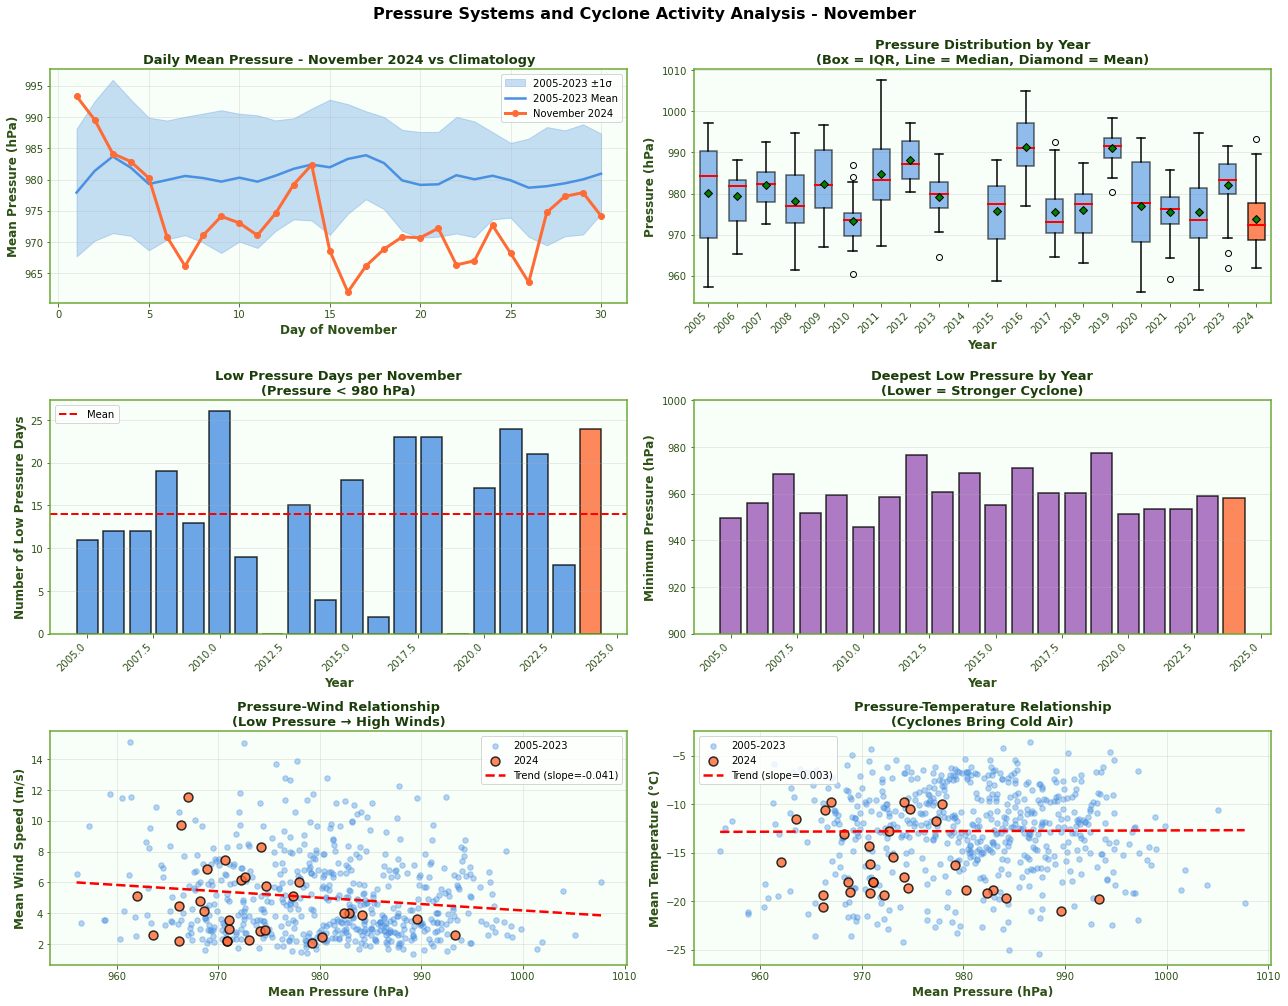

In [10]:
# Calculate daily pressure statistics for each November
daily_pressure_stats = []

for year in sorted(november_data['Year'].unique()):
    year_data = november_data[november_data['Year'] == year].copy()
    
    # group by day to get daily statistics
    for day in year_data['Day'].unique():
        day_data = year_data[year_data['Day'] == day]
        
        if len(day_data) > 0:
            daily_pressure_stats.append({
                'Year': year,
                'Day': day,
                'Mean_Pressure': day_data['Pressure (hPa)'].mean(),
                'Min_Pressure': day_data['Pressure (hPa)'].min(),
                'Pressure_Std': day_data['Pressure (hPa)'].std(),
                'Mean_Wind': day_data['Wind Speed (m/s)'].mean(),
                'Mean_Temp': day_data['Temperature (C)'].mean()
            })

daily_df = pd.DataFrame(daily_pressure_stats)

# Calculate pressure variability 
yearly_pressure_variability = daily_df.groupby('Year').agg({
    'Mean_Pressure': ['mean', 'std'],
    'Min_Pressure': 'min',
    'Pressure_Std': 'mean',
    'Mean_Wind': 'mean'
}).reset_index()

yearly_pressure_variability.columns = ['Year', 'Pressure_Mean', 'Pressure_Std', 'Min_Pressure', 
                                         'Daily_Variability', 'Wind_Mean']

# Identify low pressure events (so less than 980)
low_pressure_threshold = 980

low_pressure_events = []
for year in sorted(daily_df['Year'].unique()):
    year_data = daily_df[daily_df['Year'] == year]
    n_low_pressure_days = (year_data['Mean_Pressure'] < low_pressure_threshold).sum()
    low_pressure_events.append({'Year': year, 'Low_Pressure_Days': n_low_pressure_days})

low_pressure_df = pd.DataFrame(low_pressure_events)

# create figure
fig = plt.figure(figsize=(18, 14))

# Subplot 1 time series of daily pressure 
ax1 = plt.subplot(3, 2, 1)

# Calculate climatological mean and std for each day
clim_daily = daily_df[daily_df['Year'] != 2024].groupby('Day').agg({
    'Mean_Pressure': ['mean', 'std']
}).reset_index()
clim_daily.columns = ['Day', 'Clim_Mean', 'Clim_Std']

# Plot
ax1.fill_between(clim_daily['Day'], 
                 clim_daily['Clim_Mean'] - clim_daily['Clim_Std'],
                 clim_daily['Clim_Mean'] + clim_daily['Clim_Std'],
                 color='#4a90e2', alpha=0.3, label='2005-2023 ±1σ')
ax1.plot(clim_daily['Day'], clim_daily['Clim_Mean'], 
         color='#4a90e2', linewidth=2.5, label='2005-2023 Mean')

# Plot 2024
if 2024 in daily_df['Year'].values:
    daily_2024 = daily_df[daily_df['Year'] == 2024]
    ax1.plot(daily_2024['Day'], daily_2024['Mean_Pressure'], 
             color='#ff6b35', linewidth=3, marker='o', markersize=6, 
             label='November 2024', zorder=5)

ax1.set_xlabel('Day of November', fontsize=12, fontweight='bold', color='#2d5016')
ax1.set_ylabel('Mean Pressure (hPa)', fontsize=12, fontweight='bold', color='#2d5016')
ax1.set_title('Daily Mean Pressure - November 2024 vs Climatology', 
              fontsize=13, fontweight='bold', color='#1a3d0a')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#f8fff8')

# Subplot 2 box and whisker
ax2 = plt.subplot(3, 2, 2)

# Prepare data for box plot
pressure_by_year = [daily_df[daily_df['Year'] == year]['Mean_Pressure'].values 
                    for year in sorted(daily_df['Year'].unique())]
years = sorted(daily_df['Year'].unique())

# ceate box plot
bp = ax2.boxplot(pressure_by_year, positions=range(len(years)), widths=0.6,
                  patch_artist=True, showmeans=True,
                  boxprops=dict(facecolor='#4a90e2', alpha=0.6, edgecolor='black', linewidth=1.5),
                  whiskerprops=dict(color='black', linewidth=1.5),
                  capprops=dict(color='black', linewidth=1.5),
                  medianprops=dict(color='red', linewidth=2),
                  meanprops=dict(marker='D', markerfacecolor='green', markeredgecolor='black', markersize=6))

# Highlight 2024
if 2024 in years:
    idx_2024 = years.index(2024)
    bp['boxes'][idx_2024].set_facecolor('#ff6b35')
    bp['boxes'][idx_2024].set_alpha(0.8)

ax2.set_xlabel('Year', fontsize=12, fontweight='bold', color='#2d5016')
ax2.set_ylabel('Pressure (hPa)', fontsize=12, fontweight='bold', color='#2d5016')
ax2.set_title('Pressure Distribution by Year\n(Box = IQR, Line = Median, Diamond = Mean)', 
              fontsize=13, fontweight='bold', color='#1a3d0a')
ax2.set_xticks(range(len(years)))
ax2.set_xticklabels(years, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_facecolor('#f8fff8')

# Subplot 3 low pressure event freq
ax3 = plt.subplot(3, 2, 3)
colors_low = ['#ff6b35' if year == 2024 else '#4a90e2' for year in low_pressure_df['Year']]
ax3.bar(low_pressure_df['Year'], low_pressure_df['Low_Pressure_Days'], 
        color=colors_low, alpha=0.8, edgecolor='black', linewidth=1.5)

ax3.axhline(y=low_pressure_df['Low_Pressure_Days'].mean(), 
            color='red', linestyle='--', linewidth=2, label='Mean')
ax3.set_xlabel('Year', fontsize=12, fontweight='bold', color='#2d5016')
ax3.set_ylabel('Number of Low Pressure Days', fontsize=12, fontweight='bold', color='#2d5016')
ax3.set_title(f'Low Pressure Days per November\n(Pressure < {low_pressure_threshold} hPa)', 
              fontsize=13, fontweight='bold', color='#1a3d0a')
ax3.legend(loc='upper left', fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_facecolor('#f8fff8')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Subplot 4 min pressure by year
ax4 = plt.subplot(3, 2, 4)
colors_min = ['#ff6b35' if year == 2024 else '#9b59b6' for year in yearly_pressure_variability['Year']]
ax4.bar(yearly_pressure_variability['Year'], yearly_pressure_variability['Min_Pressure'], 
        color=colors_min, alpha=0.8, edgecolor='black', linewidth=1.5)

ax4.set_xlabel('Year', fontsize=12, fontweight='bold', color='#2d5016')
ax4.set_ylabel('Minimum Pressure (hPa)', fontsize=12, fontweight='bold', color='#2d5016')
ax4.set_title('Deepest Low Pressure by Year\n(Lower = Stronger Cyclone)', 
              fontsize=13, fontweight='bold', color='#1a3d0a')
ax4.set_ylim([900, 1000])  # Focused y-axis range
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_facecolor('#f8fff8')
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

#Subplot 5 pressure wind relations
ax5 = plt.subplot(3, 2, 5)
# Separate 2024 from other years
other_years = daily_df[daily_df['Year'] != 2024]
year_2024_daily = daily_df[daily_df['Year'] == 2024]

ax5.scatter(other_years['Mean_Pressure'], other_years['Mean_Wind'], 
            alpha=0.4, s=30, color='#4a90e2', label='2005-2023')
if len(year_2024_daily) > 0:
    ax5.scatter(year_2024_daily['Mean_Pressure'], year_2024_daily['Mean_Wind'], 
                alpha=0.8, s=80, color='#ff6b35', edgecolors='black', 
                linewidth=1.5, label='2024', zorder=5)

# Trend line
valid_mask = ~daily_df['Mean_Pressure'].isna() & ~daily_df['Mean_Wind'].isna()
if valid_mask.sum() > 1:
    z = np.polyfit(daily_df[valid_mask]['Mean_Pressure'], daily_df[valid_mask]['Mean_Wind'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(daily_df['Mean_Pressure'].min(), daily_df['Mean_Pressure'].max(), 100)
    ax5.plot(x_trend, p(x_trend), 'r--', linewidth=2.5, label=f'Trend (slope={z[0]:.3f})', zorder=10)

ax5.set_xlabel('Mean Pressure (hPa)', fontsize=12, fontweight='bold', color='#2d5016')
ax5.set_ylabel('Mean Wind Speed (m/s)', fontsize=12, fontweight='bold', color='#2d5016')
ax5.set_title('Pressure-Wind Relationship\n(Low Pressure → High Winds)', 
              fontsize=13, fontweight='bold', color='#1a3d0a')
ax5.legend(loc='upper right', fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.set_facecolor('#f8fff8')

# Subplot 6 pressure-temp relations
ax6 = plt.subplot(3, 2, 6)
ax6.scatter(other_years['Mean_Pressure'], other_years['Mean_Temp'], 
            alpha=0.4, s=30, color='#4a90e2', label='2005-2023')
if len(year_2024_daily) > 0:
    ax6.scatter(year_2024_daily['Mean_Pressure'], year_2024_daily['Mean_Temp'], 
                alpha=0.8, s=80, color='#ff6b35', edgecolors='black', 
                linewidth=1.5, label='2024', zorder=5)

# Trend line again
valid_mask = ~daily_df['Mean_Pressure'].isna() & ~daily_df['Mean_Temp'].isna()
if valid_mask.sum() > 1:
    z = np.polyfit(daily_df[valid_mask]['Mean_Pressure'], daily_df[valid_mask]['Mean_Temp'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(daily_df['Mean_Pressure'].min(), daily_df['Mean_Pressure'].max(), 100)
    ax6.plot(x_trend, p(x_trend), 'r--', linewidth=2.5, label=f'Trend (slope={z[0]:.3f})', zorder=10)

ax6.set_xlabel('Mean Pressure (hPa)', fontsize=12, fontweight='bold', color='#2d5016')
ax6.set_ylabel('Mean Temperature (°C)', fontsize=12, fontweight='bold', color='#2d5016')
ax6.set_title('Pressure-Temperature Relationship\n(Cyclones Bring Cold Air)', 
              fontsize=13, fontweight='bold', color='#1a3d0a')
ax6.legend(loc='upper left', fontsize=10)
ax6.grid(True, alpha=0.3)
ax6.set_facecolor('#f8fff8')

# Styling
for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    for spine in ax.spines.values():
        spine.set_edgecolor('#6ba832')
        spine.set_linewidth(1.5)
    ax.tick_params(labelsize=10, colors='#2d5016')

fig.suptitle('Pressure Systems and Cyclone Activity Analysis - November', 
             fontsize=16, fontweight='bold', y=0.995)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

### Statistics/Summary for Pressure Systems/Cyclone Plots

In [11]:
print("Key Cyclone and Pressure System Stats")
print("="*50)

# pressure wind relations
print("Pressure-wind relationship")
valid_mask = ~daily_df['Mean_Pressure'].isna() & ~daily_df['Mean_Wind'].isna()
pressure_clean = daily_df[valid_mask]['Mean_Pressure']
wind_clean = daily_df[valid_mask]['Mean_Wind']

slope_pw, intercept_pw, r_value_pw, p_value_pw, std_err_pw = stats.linregress(pressure_clean, wind_clean)

print(f"\nCorrelation Coefficient (r): {r_value_pw:.4f}")
print(f"R-squared (r²): {r_value_pw**2:.4f}")
print(f"P-value: {p_value_pw:.6f}")

# pressure temperature Relationship 
print("Pressure-Temperature Relationhsip")
valid_mask = ~daily_df['Mean_Pressure'].isna() & ~daily_df['Mean_Temp'].isna()
pressure_clean = daily_df[valid_mask]['Mean_Pressure']
temp_clean = daily_df[valid_mask]['Mean_Temp']

slope_pt, intercept_pt, r_value_pt, p_value_pt, std_err_pt = stats.linregress(pressure_clean, temp_clean)

print(f"\nCorrelation Coefficient (r): {r_value_pt:.4f}")
print(f"R-squared (r²): {r_value_pt**2:.4f}")
print(f"P-value: {p_value_pt:.6f}")

# 2024 Percentile Rankings
print("2024 Percentile Rankings")

if 2024 in yearly_pressure_variability['Year'].values:
    data_2024 = yearly_pressure_variability[yearly_pressure_variability['Year'] == 2024].iloc[0]
    
    # mean presssure percentiles 
    clim_pressure = yearly_pressure_variability[yearly_pressure_variability['Year'] != 2024]['Pressure_Mean']
    pressure_percentile = stats.percentileofscore(clim_pressure, data_2024['Pressure_Mean'])
    
    # min pressure percentile
    clim_min_pressure = yearly_pressure_variability[yearly_pressure_variability['Year'] != 2024]['Min_Pressure']
    min_pressure_percentile = stats.percentileofscore(clim_min_pressure, data_2024['Min_Pressure'])
    
    print(f"\n2024 Mean Pressure: {pressure_percentile:.1f}th percentile")
    print(f"2024 Minimum Pressure: {min_pressure_percentile:.1f}th percentile")
    
    # low pressure percentile 
    if 2024 in low_pressure_df['Year'].values:
        low_2024 = low_pressure_df[low_pressure_df['Year'] == 2024].iloc[0]['Low_Pressure_Days']
        clim_low_days = low_pressure_df[low_pressure_df['Year'] != 2024]['Low_Pressure_Days']
        low_days_percentile = stats.percentileofscore(clim_low_days, low_2024)
        print(f"2024 Low Pressure Days: {low_days_percentile:.1f}th percentile")

Key Cyclone and Pressure System Stats
Pressure-wind relationship

Correlation Coefficient (r): -0.1454
R-squared (r²): 0.0211
P-value: 0.000367
Pressure-Temperature Relationhsip

Correlation Coefficient (r): 0.0071
R-squared (r²): 0.0000
P-value: 0.863352
2024 Percentile Rankings

2024 Mean Pressure: 5.3th percentile
2024 Minimum Pressure: 42.1th percentile
2024 Low Pressure Days: 94.7th percentile


### Pressure Analysis

The six-panel plot shows that November 2024 was markedly more dynamically active than a typical November in the 2005–2023 climatology. Daily pressures in 2024 tracked well below the climatological mean throughout most of the month, with the daily series revealing much larger day-to-day variability compared to the climatology. This month included both an unusually deep trough around mid-month and higher pressures at the start, underscoring large synoptic swings. The year-to-year box plot reinforces this. While 2024 does not sit at the very bottom of the historical range, its median pressure places it among the lower years in the record, and the box extends across a moderately wide range suggesting variable conditions.

Low-pressure event frequency (<980 hPa) is where 2024 is most visually distinct. The bar chart shows 2024 (highlighted in orange) recorded 24 low-pressure days, substantially higher than most other years and well above the red dashed mean line at 13.5 days. This places 2024 at the 95th percentile of the historical distribution. Although the minimum pressure bar for 2024 shows values comparable to several other years on the focused 900–1000 hPa scale, the frequency of low-pressure conditions is notably elevated!

The pressure–wind scatter plot shows considerable spread across all years, with the overall trend line indicating a weak negative correlation (r = –0.15, r² = 0.02, p < 0.001). While statistically significant, this relationship explains very little of the variance. The 2024 points (orange) are scattered throughout the plot, suggesting that during this month low-pressure systems were sometimes associated with higher winds, though not uniformly.

The pressure–temperature scatter plot shows an even weaker relationship climatologically, with the trend line appearing nearly flat (r ≈ 0.01, r² < 0.001, p = 0.18), indicating essentially no meaningful connection between pressure and temperature across the full dataset. The 2024 points appear scattered across the pressure range, with some clustering toward lower pressures and colder temperatures, but no clear pattern emerges visually.

Taken together. the consistently lower mean pressure visible in the daily time series, the elevated bar for low-pressure days (95th percentile), and the box plot position, the evidence suggests that November 2024 experienced more frequent low-pressure conditions rather than record-breaking pressure extremes. While the pressure-wind and pressure-temperature relationships remain weak overall, the persistence of low-pressure systems throughout the month may have contributed to the cold anomalies through their frequency rather than their intensity.